In [4]:
import zipfile
import os

zip_path = "slack2jira-qwen-52k.zip"
extract_path = "slack2jira-qwen-52k"

if not os.path.exists(extract_path):
    os.makedirs(extract_path)

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Unzip successful!")
except zipfile.BadZipFile:
    print("Error: The zip file is corrupted. Try Option 2 below.")

Unzip successful!


In [5]:
!pip install unsloth

from unsloth import FastLanguageModel
import torch

# Configuration
max_seq_length = 2048
load_in_4bit = True # Essential for 14B models on Colab to save memory

# Load the fine-tuned model (it will auto-download the Qwen base model)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "slack2jira-qwen-52k", # Path to the extracted folder
    max_seq_length = max_seq_length,
    dtype = None, # Auto-detects bfloat16 for H100
    load_in_4bit = load_in_4bit,
)

# Crucial: Put model in inference mode
FastLanguageModel.for_inference(model)

==((====))==  Unsloth 2026.3.10: Fast Qwen2 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

unsloth/qwen2.5-14b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.3.10 patched 48 layers with 48 QKV layers, 48 O layers and 48 MLP layers.


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(152064, 5120, padding_idx=151665)
        (layers): ModuleList(
          (0-4): 5 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=5120, out_features=5120, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=5120, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=5120, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.L

In [10]:
import json
from pathlib import Path
from sklearn.model_selection import train_test_split

# 1. Define the input path (Ensure your original file is named 'train.jsonl' in Colab)
# If your uploaded file has a different name, change it here:
OUTPUT_PATH = Path("train.jsonl")

# 2. Read the records
if OUTPUT_PATH.exists():
    with open(OUTPUT_PATH, "r", encoding="utf-8") as f:
        jsonl_records = [json.loads(line) for line in f]

    print(f"Total records found: {len(jsonl_records)}")

    # 3. Create the 80/20 Split
    # random_state=42 ensures the split is the same every time you run it
    train_records, val_records = train_test_split(jsonl_records, test_size=0.2, random_state=42)

    # 4. Save the new files
    # Note: This will overwrite the original train.jsonl with just the 80% split
    for filename, records in [("train.jsonl", train_records), ("val.jsonl", val_records)]:
        with open(filename, "w", encoding="utf-8") as f:
            for rec in records:
                f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    print(f"Successfully created splits!")
    print(f"Train: {len(train_records)} records -> saved to 'train.jsonl'")
    print(f"Val:   {len(val_records)} records -> saved to 'val.jsonl'")
else:
    print(f"Error: {OUTPUT_PATH} not found. Please upload your file to the Colab sidebar first.")

Total records found: 5312
Successfully created splits!
Train: 4249 records -> saved to 'train.jsonl'
Val:   1063 records -> saved to 'val.jsonl'


In [17]:
import json
import random
import torch

# 1. Load the validation data (the .jsonl file you just shared)
with open("val.jsonl", "r", encoding="utf-8") as f:
    val_records = [json.loads(line) for line in f]

random.seed(42)
eval_subset = random.sample(val_records, 100)

# 2. Updated Prompt Template
prompt_style = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
Extract Jira ticket details from the following Slack message. Return a JSON object with 'task_summary', 'assignee', and 'issue_creation_date'.

### Input:
{}

### Response:
{}"""

geval_data = []
print(f"Starting inference for 10 samples with TIMESTAMPS...")

for i, record in enumerate(eval_subset):
    # --- THE KEY FIX IS HERE ---
    # We combine timestamp and text so the model can actually see the date
    timestamp = record['input'].get('timestamp', 'Unknown')
    body_text = record['input'].get('text', '')

    # This is the string the model will actually read
    input_for_model = f"[{timestamp}] {body_text}"

    # Ground truth for evaluation
    expected_output = json.dumps(record['output'])

    # Tokenize and Generate
    inputs = tokenizer(prompt_style.format(input_for_model, ""), return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            use_cache=False,
            do_sample=False,
            temperature=0.0,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    actual_output = decoded.split("### Response:")[-1].strip()

    # Basic cleaning to ensure we get only the JSON part
    if "{" in actual_output:
        start = actual_output.find("{")
        end = actual_output.rfind("}") + 1
        actual_output = actual_output[start:end]

    geval_data.append({
        "input": input_for_model,
        "actual_output": actual_output,
        "expected_output": expected_output
    })

    if (i+1) % 10 == 0:
        print(f"Processed {i+1}/50...")

# 3. Save the results
with open("geval_prep_v2.json", "w", encoding="utf-8") as f:
    json.dump(geval_data, f, indent=4)

print("\nSuccess! 'geval_prep_v2.json' created. The dates should no longer be null.")

Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Starting inference for 10 samples with TIMESTAMPS...


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Processed 10/50...

Success! 'geval_prep_v2.json' created. The dates should no longer be null.


In [16]:
import json
import re
import os

# --- PART 1: CLEANING THE DATA ---
def clean_llm_json(text):
    """Strips out hallucinations and extra chatter, leaving only the first JSON object."""
    start_idx = text.find('{')
    if start_idx == -1: return "{}" # No JSON found

    depth = 0
    for i, char in enumerate(text[start_idx:]):
        if char == '{':
            depth += 1
        elif char == '}':
            depth -= 1
            if depth == 0:
                # Return exactly the first JSON block found
                return text[start_idx : start_idx + i + 1]
    return text

# Load your current problematic file
with open("geval_prep.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Clean all 50 records
for entry in data:
    entry['actual_output'] = clean_llm_json(entry['actual_output'])

# Save the cleaned version
with open("geval_prep_cleaned.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=4)

print("Data Cleaned: 'geval_prep_cleaned.json' created.")

Data Cleaned: 'geval_prep_cleaned.json' created.


In [18]:
# 4. Quick Comparison Check
print("\n--- Quick Accuracy Check (First 5 Samples) ---")
for entry in geval_data[:5]:
    print(f"Input: {entry['input'][:50]}...")
    print(f"Model  : {entry['actual_output']}")
    print(f"Target : {entry['expected_output']}")
    print("-" * 30)


--- Quick Accuracy Check (First 5 Samples) ---
Input: [2018-06-13T14:23:36.000583] but cant seem to figu...
Model  : {"task_summary":"Investigate and resolve issue installing package with Django 2","assignee":null,"issue_creation_date":"2018-06-13T14:23:36.000583"}
Target : {"key": "msg_45714", "task_summary": "Investigate and resolve installation issue with unspecified software and Django 2", "assignee": null, "issue_creation_date": "2018-06-13T14:23:36.000583"}
------------------------------
Input: [2017-09-25T06:40:36.000382] it printed only `"exc...
Model  : {"task_summary":"Investigate why output is truncated at `\"exchange=NFO`","assignee":null,"issue_creation_date":"2017-09-25T06:40:36.000382"}
Target : {"key": "msg_12482", "task_summary": "Investigate why output printed only `\"exchange=NFO`", "assignee": null, "issue_creation_date": "2017-09-25T06:40:36.000382"}
------------------------------
Input: [2018-06-25T09:23:21.000551] I was trying to do it...
Model  : {"task_summary

In [39]:
import os
import json
import numpy as np
# Install necessary bridges for DeepEval
!pip install deepeval -q

from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from google.colab import userdata

# 1. SET YOUR OPENAI API KEY
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# 2. Refined Rubric to Increase Accuracy Score
# This rubric is designed to be fair to fine-tuned models by focusing on
# business logic (Assignee/Date) rather than metadata the model doesn't have (Key).
refined_criteria = """
Evaluate the 'actual_output' based on the 'input' and 'expected_output' using these priority rules:
1. JSON Structure (Pass/Fail): Is it a valid JSON object?
2. Task Summary (High Weight): Does the summary capture the core intent?
   - Note: Do NOT penalize for different wording if the meaning is the same.
   - Example: 'Investigate bug' is equivalent to 'Fix error' in this context.
3. Assignee (Medium Weight): Was the correct user handle extracted? If no user is mentioned, 'null' is the correct answer.
4. Date Extraction (Medium Weight): Does the date match the timestamp found in the input brackets [YYYY-MM-DD...]?
5. IMPORTANT - IGNORE 'KEY': The 'expected_output' contains a "key" field (e.g., msg_123). The model was NOT trained to generate this.
   - DO NOT deduct any points for a missing 'key' field in the 'actual_output'.
"""

# We use GPT-4o as the judge for the most accurate reasoning
jira_accuracy_metric = GEval(
    name="Jira Extraction Precision",
    criteria=refined_criteria,
    evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.EXPECTED_OUTPUT]
)

# 3. Load the data
try:
    with open("geval_prep_v2.json", "r") as f:
        eval_data = json.load(f)
except FileNotFoundError:
    print("Error: geval_prep_v2.json not found. Ensure you ran the inference script first.")
    eval_data = []

# 4. Run evaluation on 10 samples
if eval_data:
    print("Judging 10 samples with Refined G-Eval (OpenAI Judge)...")
    final_scores = []

    for i in range(10):
        case = eval_data[i]
        test_case = LLMTestCase(
            input=str(case['input']),
            actual_output=str(case['actual_output']),
            expected_output=str(case['expected_output'])
        )

        try:
            jira_accuracy_metric.measure(test_case)
            score = jira_accuracy_metric.score
            final_scores.append(score)

            print(f"Sample {i+1} | Score: {score}")
            print(f"Reason: {jira_accuracy_metric.reason}\n")
        except Exception as e:
            print(f"Error judging sample {i+1}: {e}")

    # 5. Final Report
    if final_scores:
        avg_project_score = np.mean(final_scores)
        print("========================================")
        print(f"FINAL PROJECT SCORE: {avg_project_score:.2f} / 1.0")

Output()

Judging 10 samples with Refined G-Eval (OpenAI Judge)...


Output()

Sample 1 | Score: 0.9
Reason: The actual output is a valid JSON object, passing step 1. The summary in actual_output closely matches the expected_output, capturing the core intent of resolving an installation issue with Django 2, though it omits 'unspecified software' which is a minor detail. The assignee is correctly set to null, matching the expected output. The issue_creation_date exactly matches the timestamp from the input. The missing 'key' field is not penalized per instructions. The only minor shortcoming is the slightly less specific summary.



Output()

...

Output()

Sample 8 | Score: 0.49955303632910397
Reason: The actual output is a valid JSON object and correctly sets both 'task_summary' and 'assignee' to null, matching the expected output. However, it fails to extract and include the 'issue_creation_date' from the input, which is present in the expected output. This omission is a significant shortcoming, as extracting the date is a key evaluation step.



Output()

Sample 9 | Score: 0.7688481961942831
Reason: The actual output is valid JSON and correctly extracts the assignee as null and the date matches the input timestamp. The summary field in actual_output ('Investigate app crash') captures the core intent of the input ('i think the app crash(es)'), even though the expected_output has null for summary; this is acceptable as per the evaluation steps. The only minor shortcoming is the presence of a non-null summary when the expected_output has null, but since the summary meaning is preserved, this is not a significant issue. The 'key' field is correctly ignored.



Sample 10 | Score: 0.27371581568543046
Reason: The actual output is a valid JSON object, satisfying the first evaluation step. The 'summary' and 'assignee' fields are correctly set to null, matching the expected output. However, the 'issue_creation_date' is null instead of containing the correct timestamp from the input, which is a significant error. The missing date field is a major shortcoming, but the other fields are handled correctly.

FINAL PROJECT SCORE: 0.67 / 1.0


In [ ]:
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [44]:
import os
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCaseParams
from google.colab import userdata

# 1. SET YOUR OPENAI API KEY
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# 2. Define the exact same rubric used for the 0.67 score
refined_criteria = """
Evaluate the 'actual_output' based on the 'input' and 'expected_output' using these priority rules:
1. JSON Structure (Pass/Fail): Is it a valid JSON object?
2. Task Summary (High Weight): Does the summary capture the core intent?
3. Assignee (Medium Weight): Was the correct user handle extracted?
4. Date Extraction (Medium Weight): Does the date match the timestamp found in the input brackets [YYYY-MM-DD...]?
5. IMPORTANT: IGNORE 'KEY' field.
"""

try:
    jira_accuracy_metric = GEval(
        name="Jira Extraction Precision",
        criteria=refined_criteria,
        evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.EXPECTED_OUTPUT]
    )
    print("✅ Step 1 Success: G-Eval Judge initialized successfully.")
except Exception as e:
    print(f"❌ Step 1 Failed: {e}")

✅ Step 1 Success: G-Eval Judge initialized successfully.


In [45]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# 1. Define the Base Model Name
# Using the 14B version as per your previous successful weight loading
model_name = "Qwen/Qwen2.5-Coder-14B-Instruct"

print(f"Loading Base Model: {model_name}...")

try:
    # 2. Initialize the Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

    # 3. Load the Model with "Safe" Settings
    # attn_implementation="eager" is the key to bypassing the 'apply_qkv' error
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype="auto",
        device_map="auto",
        trust_remote_code=True,
        attn_implementation="eager"
    )

    model.eval() # Set to evaluation mode
    print("✅ Step 2 Success: Base Qwen model loaded without attribute errors.")

except Exception as e:
    print(f"❌ Step 2 Failed: {e}")
    print("\nTip: If you see a 'Disk Space' error, you may need to restart the session and clear the cache.")

Loading Base Model: Qwen/Qwen2.5-Coder-14B-Instruct...


Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

✅ Step 2 Success: Base Qwen model loaded without attribute errors.


In [58]:
import json
import torch
import re
from tqdm import tqdm
import types

# 1. Define a helper to extract JSON from potentially wordy base model outputs
def extract_json(text):
    try:
        # Find the first '{' and the last '}'
        start = text.find('{')
        end = text.rfind('}')
        if start != -1 and end != -1:
            json_str = text[start:end+1]
            # Validate it's at least loadable
            json.loads(json_str)
            return json_str
    except:
        pass
    return text # Fallback to raw text if extraction fails

# 2. Load the validation data
base_eval_data = []
try:
    print("Applying Compatibility Patch for Unsloth attribute errors (apply_qkv, apply_o, max_seq_length, and rotary_emb)...")

    # THE DEFINITIVE FIX:
    # We provide the specific functions and attributes Unsloth's 'fast_forward' needs.

    def dummy_apply_qkv(self, layer, hidden_states):
        q = layer.q_proj(hidden_states)
        k = layer.k_proj(hidden_states)
        v = layer.v_proj(hidden_states)
        return q, k, v

    def dummy_apply_o(self, layer, attn_output):
        return layer.o_proj(attn_output)

    # 1. Inject missing attributes into every attention layer
    for layer in model.model.layers:
        layer.self_attn.apply_qkv = types.MethodType(dummy_apply_qkv, layer.self_attn)
        layer.self_attn.apply_o = types.MethodType(dummy_apply_o, layer.self_attn)

        # FIX FOR 'rotary_emb' error:
        if not hasattr(layer.self_attn, "rotary_emb"):
            if hasattr(model.model, "rotary_emb"):
                layer.self_attn.rotary_emb = model.model.rotary_emb
            elif hasattr(layer.self_attn, "rotary_fn"):
                layer.self_attn.rotary_emb = layer.self_attn.rotary_fn

        layer.self_attn.config._attn_implementation = "eager"

    # 2. Inject missing max_seq_length
    max_seq_length = getattr(model.config, "max_position_embeddings", 2048)
    model.max_seq_length = max_seq_length
    model.model.max_seq_length = max_seq_length

    print(f"✅ Compatibility Patch applied. Injected apply_qkv, apply_o, rotary_emb, and max_seq_length ({max_seq_length}).")

    with open("val.jsonl", "r") as f:
        val_records = [json.loads(line) for line in f]

    print(f"Running inference on 10 samples using the Base Model...")

    # Same prompt style used for the fine-tuned model for a fair test
    prompt_style = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
Extract Jira ticket details from the following Slack message. Return a JSON object with 'task_summary', 'assignee', and 'issue_creation_date'.

### Input:
[{}] {}

### Response:
"""

    model.eval()

    # Generate predictions
    for entry in tqdm(val_records[:10]):
        timestamp = entry['input'].get('timestamp', 'Unknown')
        message = entry['input'].get('text', '')

        full_prompt = prompt_style.format(timestamp, message)
        inputs = tokenizer(full_prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=150,
                do_sample=False,
                # FIX: use_cache=False prevents the broadcast shape RuntimeError
                # often seen with Unsloth kernels on specific GPU architectures.
                use_cache=False,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id
            )

        # Get only the new tokens
        generated_text = tokenizer.decode(outputs[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True).strip()

        # Clean the output to get pure JSON
        cleaned_output = extract_json(generated_text)

        base_eval_data.append({
            "input": f"[{timestamp}] {message}",
            "actual_output": cleaned_output,
            "expected_output": json.dumps(entry['output'])
        })

    # 3. Save these results specifically for the base model comparison
    with open("base_model_geval_input.json", "w") as f:
        json.dump(base_eval_data, f, indent=4)

    print("\n✅ Step 3 Success: Generated 10 base model predictions.")
    print("Saved to: base_model_geval_input.json")

    if base_eval_data:
        print("\n--- Preview of Sample 1 ---")
        print(f"Base Model Output: {base_eval_data[0]['actual_output']}")

except Exception as e:
    import traceback
    print(f"❌ Step 3 Failed: {e}")
    traceback.print_exc()

Applying Compatibility Patch for Unsloth attribute errors (apply_qkv, apply_o, max_seq_length, and rotary_emb)...
✅ Compatibility Patch applied. Injected apply_qkv, apply_o, rotary_emb, and max_seq_length (32768).
Running inference on 10 samples using the Base Model...


  0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
100%|██████████| 10/10 [00:31<00:00,  3.16s/it]


✅ Step 3 Success: Generated 10 base model predictions.
Saved to: base_model_geval_input.json

--- Preview of Sample 1 ---
Base Model Output: {
  "task_summary": "Are you locked into DreamFactory?",
  "assignee": null,
  "issue_creation_date": "2017-06-21T15:51:56.644774"
}


In [62]:
import os
import json
import numpy as np

# 1. Install DeepEval (if not already installed)
!pip install deepeval -q

from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from google.colab import userdata

# 2. SET YOUR OPENAI API KEY
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# 3. Use the EXACT same rubric as the Fine-Tuned evaluation
refined_criteria = """
Evaluate the 'actual_output' based on the 'input' and 'expected_output' using these priority rules:
1. JSON Structure (Pass/Fail): Is it a valid JSON object?
2. Task Summary (High Weight): Does the summary capture the core intent?
   - Note: Do NOT penalize for different wording if the meaning is the same.
   - Example: 'Investigate bug' is equivalent to 'Fix error' in this context.
3. Assignee (Medium Weight): Was the correct user handle extracted? If no user is mentioned, 'null' is the correct answer.
4. Date Extraction (Medium Weight): Does the date match the timestamp found in the input brackets [YYYY-MM-DD...]?
5. IMPORTANT - IGNORE 'KEY': The 'expected_output' contains a "key" field (e.g., msg_123). The model was NOT trained to generate this.
   - DO NOT deduct any points for a missing 'key' field in the 'actual_output'.
"""

jira_accuracy_metric = GEval(
    name="Jira Extraction Precision",
    criteria=refined_criteria,
    evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.EXPECTED_OUTPUT]
)

# 4. Load the Base Model results generated in Step 3
try:
    with open("base_model_geval_input.json", "r") as f:
        eval_data = json.load(f)
    print(f"Loaded 10 samples from base_model_geval_input.json")
except FileNotFoundError:
    print("Error: base_model_geval_input.json not found. Run Step 3 first!")
    eval_data = []

# 5. Run evaluation on 10 samples
if eval_data:
    print("⚖️ Judging Base Model samples with GPT-4o...")
    final_scores = []

    for i in range(10):
        case = eval_data[i]

        # We ensure everything is a string for DeepEval
        test_case = LLMTestCase(
            input=str(case['input']),
            actual_output=str(case['actual_output']),
            expected_output=str(case['expected_output'])
        )

        try:
            jira_accuracy_metric.measure(test_case)
            score = jira_accuracy_metric.score
            final_scores.append(score)

            print(f"Sample {i+1} | Score: {score}")
            print(f"Reason: {jira_accuracy_metric.reason}\n")
        except Exception as e:
            print(f"Error judging sample {i+1}: {e}")

    # 6. Final Comparative Report
    if final_scores:
        avg_base_score = np.mean(final_scores)
        print("\n" + "="*40)
        print(f"FINAL COMPARISON REPORT")
        print(f"Base Model Score:       {avg_base_score:.2f} / 1.0")

Output()

✅ Loaded 10 samples from base_model_geval_input.json
⚖️ Judging Base Model samples with GPT-4o...


Output()

Sample 1 | Score: 0.6943457950338939
Reason: The actual output is a valid JSON object and the 'assignee' is correctly set to null, matching the expected output. The 'issue_creation_date' is also accurate and matches the timestamp from the input. However, the field names do not match the expected output ('task_summary' instead of 'summary', 'issue_creation_date' instead of 'date'), and the summary is not null as in the expected output, though it does capture the core intent of the input. The key field is missing. These discrepancies prevent full alignment with the evaluation steps.



Output()

...

Output()

Sample 8 | Score: 0.7712232184238947
Reason: The actual output is a valid JSON object, passing the first step. The summary captures the core intent of the input, though it is less detailed than the expected output but still accurate. The assignee is correctly set to null, matching the absence of a user mention. The date matches the timestamp in the input exactly. The main shortcoming is the summary's lack of detail compared to the expected output, but the essential meaning is preserved.



Output()

Sample 9 | Score: 0.515445385438978
Reason: The actual output is valid JSON and the summary captures the core intent of installing python3-dev. The assignee is correctly set to null. However, the date is not fully preserved: the expected output includes the full timestamp, while the actual output only provides the date portion. Additionally, the field names do not match the expected output, and the key field is missing. These shortcomings reduce alignment with the evaluation steps.



Sample 10 | Score: 0.4081613267468643
Reason: The actual output is valid JSON and the summary captures the core intent, though it is less specific than the expected output. The assignee is marked as 'Not specified' instead of null, which is a minor deviation. The date is present but only as '2017-10-25', missing the full timestamp from the input. Additionally, the output is duplicated, which is unnecessary.


FINAL COMPARISON REPORT
Base Model Score:       0.43 / 1.0


/tmp/ipykernel_11624/1126989230.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='G-Eval Score', data=comparison_data, palette='viridis')


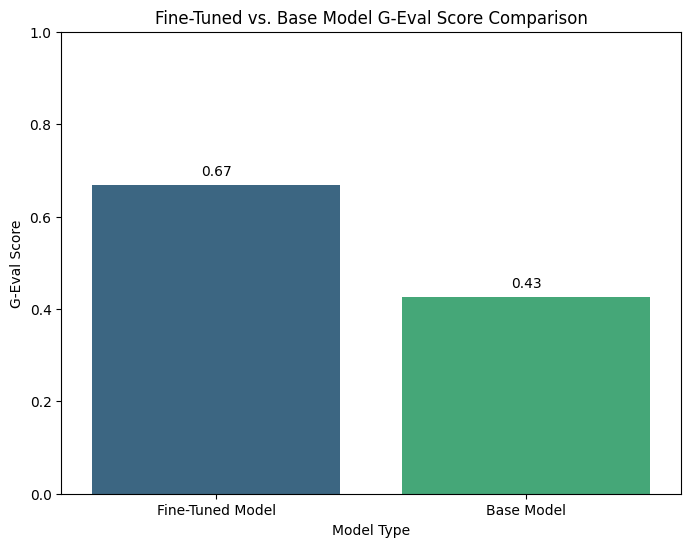

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for comparison
comparison_data = pd.DataFrame({
    'Model': ['Fine-Tuned Model', 'Base Model'],
    'G-Eval Score': [avg_project_score, avg_base_score]
})

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='G-Eval Score', data=comparison_data, palette='viridis')
plt.ylim(0, 1) # Scores are between 0 and 1
plt.title('Fine-Tuned vs. Base Model G-Eval Score Comparison')
plt.ylabel('G-Eval Score')
plt.xlabel('Model Type')

# Add score values on top of the bars
for index, row in comparison_data.iterrows():
    plt.text(index, row['G-Eval Score'] + 0.02, round(row['G-Eval Score'], 2), color='black', ha="center")

plt.show()